# Test 1: Isolated Controller and Signal
Use a modified IEEE 14-bus setup with a VSM grid-forming inverter (REGF2) replacing synchronous generator 3 (GENROU_3). 

In [1]:
# path setup
from pathlib import Path
project_dir = Path.cwd()
test_case_dir = project_dir / "test_cases" # all test case excel sheets

print(test_case_dir)

/Users/scarlett/Programming/2026 Power Grid Research/PV-virtual-inertia-estimation-noise-lag/test_cases


In [2]:
# setting up ANDES
%matplotlib inline

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import andes

andes.config_logger(stream_level=30)

import new file (pls pls work)

In [3]:
case_path = andes.get_case(test_case_dir / "test_case_simplified.xlsx")
ss_ref = andes.load(case_path)

ss_ref.PFlow.run()

gen_idxs = list(ss_ref.GENROU.idx.v)
gen_buses = list(ss_ref.GENROU.bus.v)
M_base = ss_ref.GENROU.M.v.copy()

gen_info = pd.DataFrame({"gen_idx": gen_idxs, "bus": gen_buses, "M": M_base})
gen_info.sort_values("M", ascending=False)


,gen_idx,bus,M
0,GENROU_2,2,7.4
1,GENROU_3,3,7.4


In [4]:
regf2_idxs = list(ss_ref.REGF2.idx.v)
regf2_buses = list(ss_ref.REGF2.bus.v)
#regf2_M_base = ss_ref.REGF2.M.v.copy()

gen_info = pd.DataFrame({"gen_idx": regf2_idxs, "bus": regf2_buses})
gen_info.sort_values("gen_idx", ascending=False)

,gen_idx,bus
0,REGF2_1,1


## Set Up Fault and Run TDS
Trip the synchronous generator with the highest inertia (GENROU 2) at t = 1s.  $\alpha$ (inertia scaling) set to lowest (0.15). 

In [5]:
add_idx = "PQ_3" # add a load, causing a disturbance

# inertia_scales = [1.0, 0.7, 0.5, 0.4, 0.3, 0.2, 0.15] just testing lowest
# alpha = 0.15

ss = andes.load(case_path, setup=False)
ss.add("Toggle", model="PQ", dev=add_idx, t=1.0) # add the load @ t=1s
ss.setup()
ss.config.warn_abnormal = 0
ss.GENROU.M.v[:] = M_base

ss.PFlow.run()
ss.TDS.config.tf = 8
ss.TDS.config.no_tqdm = 1
ss.TDS.config.criteria = 0 # ignore stability criteria (run until end of simulation time)

ss.TDS.run()

results = ss.TDS.get_timeseries(ss.GENROU.omega)

## Results

### COI Frequency

          GENROU_2  GENROU_3
0.000000  1.000000  1.000000
0.033333  1.000000  1.000000
0.066667  1.000000  1.000000
0.100000  1.000000  1.000000
0.133333  1.000000  1.000000
...            ...       ...
7.866767  0.999994  0.999995
7.900100  0.999993  0.999994
7.933433  0.999993  0.999994
7.966767  0.999993  0.999993
8.000000  0.999993  0.999994

[243 rows x 2 columns]


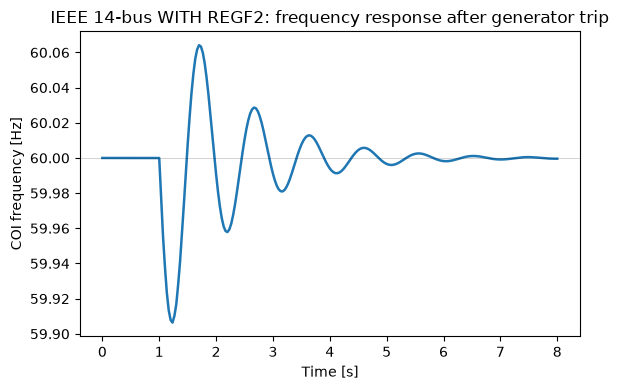

In [6]:
# plotting
weights = M_base / M_base.sum()
cmap = plt.cm.RdYlBu

fig, ax = plt.subplots(figsize=(6, 4))

print(results)

f_coi = (results.values * weights).sum(axis=1) * 60
ax.plot(results.index, f_coi, color="tab:blue", linewidth=1.8)

ax.set_xlabel("Time [s]")
ax.set_ylabel("COI frequency [Hz]")
ax.set_title("IEEE 14-bus WITH REGF2: frequency response after generator trip")
#ax.set_xlim(0.0, 5.0)
ax.axhline(60.0, color="black", linewidth=0.4, alpha=0.3)

plt.tight_layout()

### Nadir & RoCoF

In [7]:
f_coi = (results.values * weights).sum(axis=1) * 60
t = results.index.values

nadir = f_coi[t > 1.0].min()

post = (t >= 1.0) & (t <= 2.0)
t_post, f_post = t[post], f_coi[post]
rocof = np.max(np.abs(np.diff(f_post) / np.diff(t_post)))

print("Nadir: " + str(nadir))
print ("RoCoF: " + str(rocof))

Nadir: 59.90637294624585
RoCoF: 0.6761083931692703


### Voltages

In [8]:
voltage_df = ss.TDS.get_timeseries(ss.Bus.v)
print(f"Voltage DataFrame shape: {voltage_df.shape}")
print(f"Columns (bus indices): {list(voltage_df.columns)}")

Voltage DataFrame shape: (243, 5)
Columns (bus indices): [1, 2, 3, 4, 0]


(0.0, 5.0)

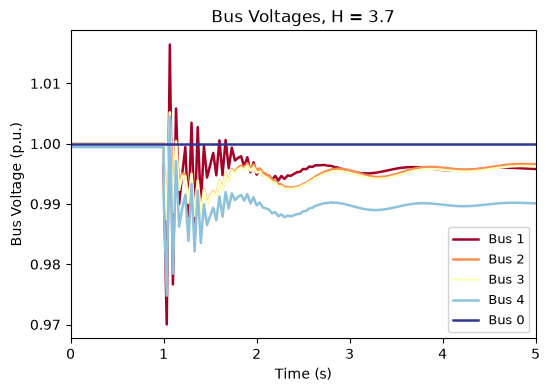

In [9]:
# Voltage at All Buses
cmap = plt.cm.RdYlBu

fig, ax = plt.subplots(figsize=(6, 4))

for i, bus in enumerate(voltage_df.columns):
    color = cmap(i / (len(voltage_df.columns) - 1))

    ax.plot(voltage_df.index, voltage_df[bus], color=color, linewidth=1.8,
            label=f"Bus {bus}")

H = np.average(M_base) / 2

ax.set_xlabel("Time (s)")
ax.set_ylabel("Bus Voltage (p.u.)")
ax.set_title(f"Bus Voltages, H = {H}")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
ax.set_xlim(0.0, 5.0)
# ax.axhline(60.0, color="black", linewidth=0.4, alpha=0.3)


### Power Delivered
Report delivered power (as measured by controller signal)

In [10]:
power_regf2_df = ss.TDS.get_timeseries(ss.REGF2.Pe)
power_regf2_df

,REGF2_1
0.000000,0.000000
0.033333,0.000000
0.066667,0.000000
0.100000,0.000000
0.133333,0.000000
...,...
7.866767,0.000034
7.900100,0.000041
7.933433,0.000047
7.966767,0.000050


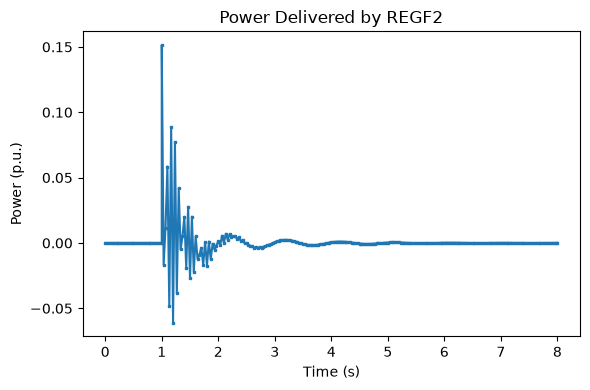

In [11]:
# --- power delivered by REGF2 ---
fig, ax = plt.subplots(figsize=(6, 4))

ax.set_title(f"Power Delivered by REGF2")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Power (p.u.)")

# plot actual
ax.plot(power_regf2_df.index, power_regf2_df, "s-", color="tab:blue",
        markersize=1.8)

plt.tight_layout()

(0.0, 5.0)

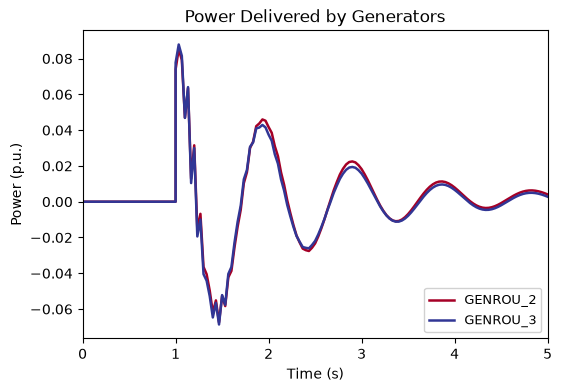

In [12]:
# Power Delivered by Generators
generator_power_df = ss.TDS.get_timeseries(ss.GENROU.Pe)
#print(generator_power_df)

cmap = plt.cm.RdYlBu

fig, ax = plt.subplots(figsize=(6, 4))

for i, gen in enumerate(generator_power_df.columns):
    color = cmap(i / (len(generator_power_df.columns) - 1))

    ax.plot(generator_power_df.index, generator_power_df[gen], color=color, linewidth=1.8,
            label=f"{gen}")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Power (p.u.)")
ax.set_title("Power Delivered by Generators")
ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
ax.set_xlim(0.0, 5.0)
# ax.axhline(60.0, color="black", linewidth=0.4, alpha=0.3)


### RoCoF
Get RoCoF at Bus 1 using a BusROCOF object.

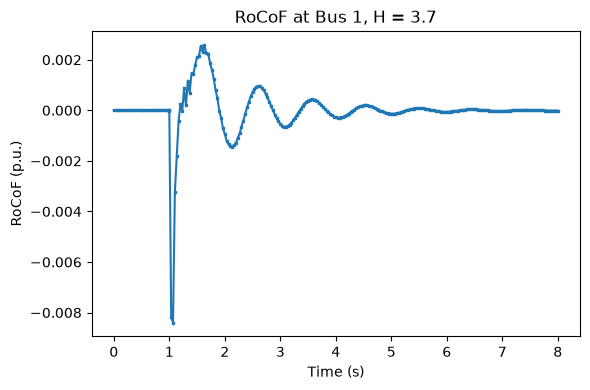

In [13]:
rocof_pu = ss.TDS.get_timeseries(ss.BusROCOF.Wf_y)

fig, ax = plt.subplots(figsize=(6, 4))

ax.set_title(f"RoCoF at Bus 1, H = {H}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("RoCoF (p.u.)")

# plot actual
ax.plot(rocof_pu.index, rocof_pu, "s-", color="tab:blue",
        markersize=1.8)

plt.tight_layout()

# Calculations
Calculate effective inertia constant H from power delivered.

In [20]:
f_0 = 60 # Hz
S_n = ss.REGF2.Sn.v[0]
P_syn = -1 * power_regf2_df # power (p.u.)

In [21]:
# calculations (PER UNIT)
H_refg2_eff = (0.5 * P_syn["REGF2_1"].div(rocof_pu["BusROCOF_1"]))
H_refg2_eff
                           

0.000000         NaN
0.033333         NaN
0.066667         NaN
0.100000         NaN
0.133333         NaN
              ...   
7.866767    1.396144
7.900100    1.667990
7.933433    1.935245
7.966767    2.224607
8.000000    2.569757
Length: 243, dtype: float64

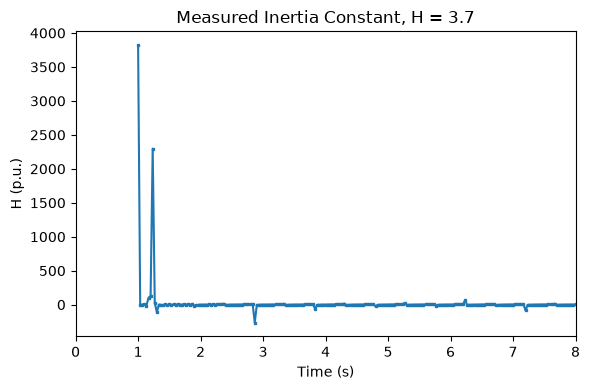

In [27]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.set_title(f"Measured Inertia Constant, H = {H}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("H (p.u.)")

# plot actual
ax.plot(H_refg2_eff.index, H_refg2_eff, "s-", color="tab:blue",
        markersize=1.8)

plt.xlim(0, 8)
#plt.ylim(-50, 50)
plt.tight_layout()